In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions_glitterin"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Make a function to save the information to the df

In [3]:
def make_fit_summary_row(fit_name, sf_results, nk):
    return {
        "Fit Case": fit_name,
        "nk": nk,
        "Scale Factor": sf_results["best_sf"],
#         "Best amax (cm)": sf_results["best_rvol_max_cm"],
        "Best amax (micron)": sf_results["best_rvol_max_micron"],
        "Best Index": sf_results["best_idx_arr"],
    }

rows_DSHARP = []

# Set variables and run glitterin

In [4]:
# Constants
BandsIndex = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2', "Band5_robust_minus1", 'Band6', 'Band7_nterms2']
# BandLabelsForPlots = ['Band 4', 'Band 5', 'Band 6', 'Band 7']

num_bands = len(BandsIndex)
 
lambda_bands_cm = {
    b: mm_to_cm(lambda_mm[b]) 
    for b in BandsIndex
}

# ms = {alma_band_ms[b]
#     for b in BandsIndex
# }

# ms


# band_colors = [alma_band_colors[b] for b in BandsIndex]

In [5]:
lambda_bands_cm['Band 4 nterms2'] = 0.207
lambda_bands_cm['Band 5 robust -1'] = 0.148
lambda_bands_cm['Band 6'] = 0.129
lambda_bands_cm['Band 7 nterms2'] = 0.087

In [6]:
lambda_bands_cm

{'Band 4 nterms2': 0.207,
 'Band 5 robust -1': 0.148,
 'Band 6': 0.129,
 'Band 7 nterms2': 0.087}

In [7]:
# Load in POLF
df_POLF = load_POLF(BandsIndex, print_things = True)

Band = Band 4 nterms2
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [np.float64(1.1646626), np.float64(1.3506356000000002), np.float64(1.41269695), np.float64(0.898293)], 'POLF_maxPOLI': [np.float64(1.561384), np.float64(1.5137895000000001), np.float64(1.4862873), np.float64(1.0841521)], 'POLF_err_maxPOLI': [np.float64(0.040507176933380004), np.float64(0.07530999086540001), np.float64(0.030210346000000003), np.float64(0.014223440147289998)], 'POLF_maxStokesI': [np.float64(1.3677061000000001), np.float64(1.4034492), np.float64(1.4639224), np.float64(1.0421403)], 'POLF_err_maxStokesI': [np.float64(0.03790606194433), np.float64(0.07426819624669001), np.float64(0.029772913), np.float64(0.0141318535827)]}


In [8]:
amin = 1e-4 # 0.1 micron lower boundary
amax = 0.5 # maximum 5000 micron
na = 1000

max_rvol_grid_cm = np.geomspace(amin, amax, na)
#np.logspace(-3, 0, 1000) 


# Original logarithmic grid
# a_grid_cm = np.geomspace(amin, amax, na)


xmin = 30#1e-3 + 20
xmax = 1e3 + 20

In [9]:
# Choose the array of a_max values we are looking at 
# Figure 12 in in 2025 has 1e-3 to 1e0 cm # This corresponds to 10 to 10000 micron 
#max_rvol_grid_cm = np.logspace(-3, 0, 1000) 



nk_data = np.genfromtxt(
    "nk_values.txt",
    dtype=None,
    names=True,
    encoding=None
)

data_n = {}
data_k = {}

for b, b_file in zip(BandsIndex, bands_naming):
    row = nk_data[nk_data["band"] == b_file][0]
    
    data_n[b] = float(row["n"])
    data_k[b] = float(row["k"])

In [10]:
# results = RunGlitterinPowerLawDistAveraged(BandsIndex, lambda_bands_cm, data_n, data_k, max_rvol_grid_cm)

# np.savez("results_glitterin_fixed_lambda.npz", results=results)

In [11]:
# data = np.load("results_glitterin.npz", allow_pickle=True)

data = np.load("results_glitterin_fixed_lambda.npz", allow_pickle=True)
results = data["results"].item()

In [12]:
min(results['Band 4 nterms2']['rvol_max_cm']) * 1e4

np.float64(1.0)

In [13]:
max(results['Band 4 nterms2']['rvol_max_cm']) * 1e4

np.float64(5000.0)

# P vs omega vs maximum grain size plot

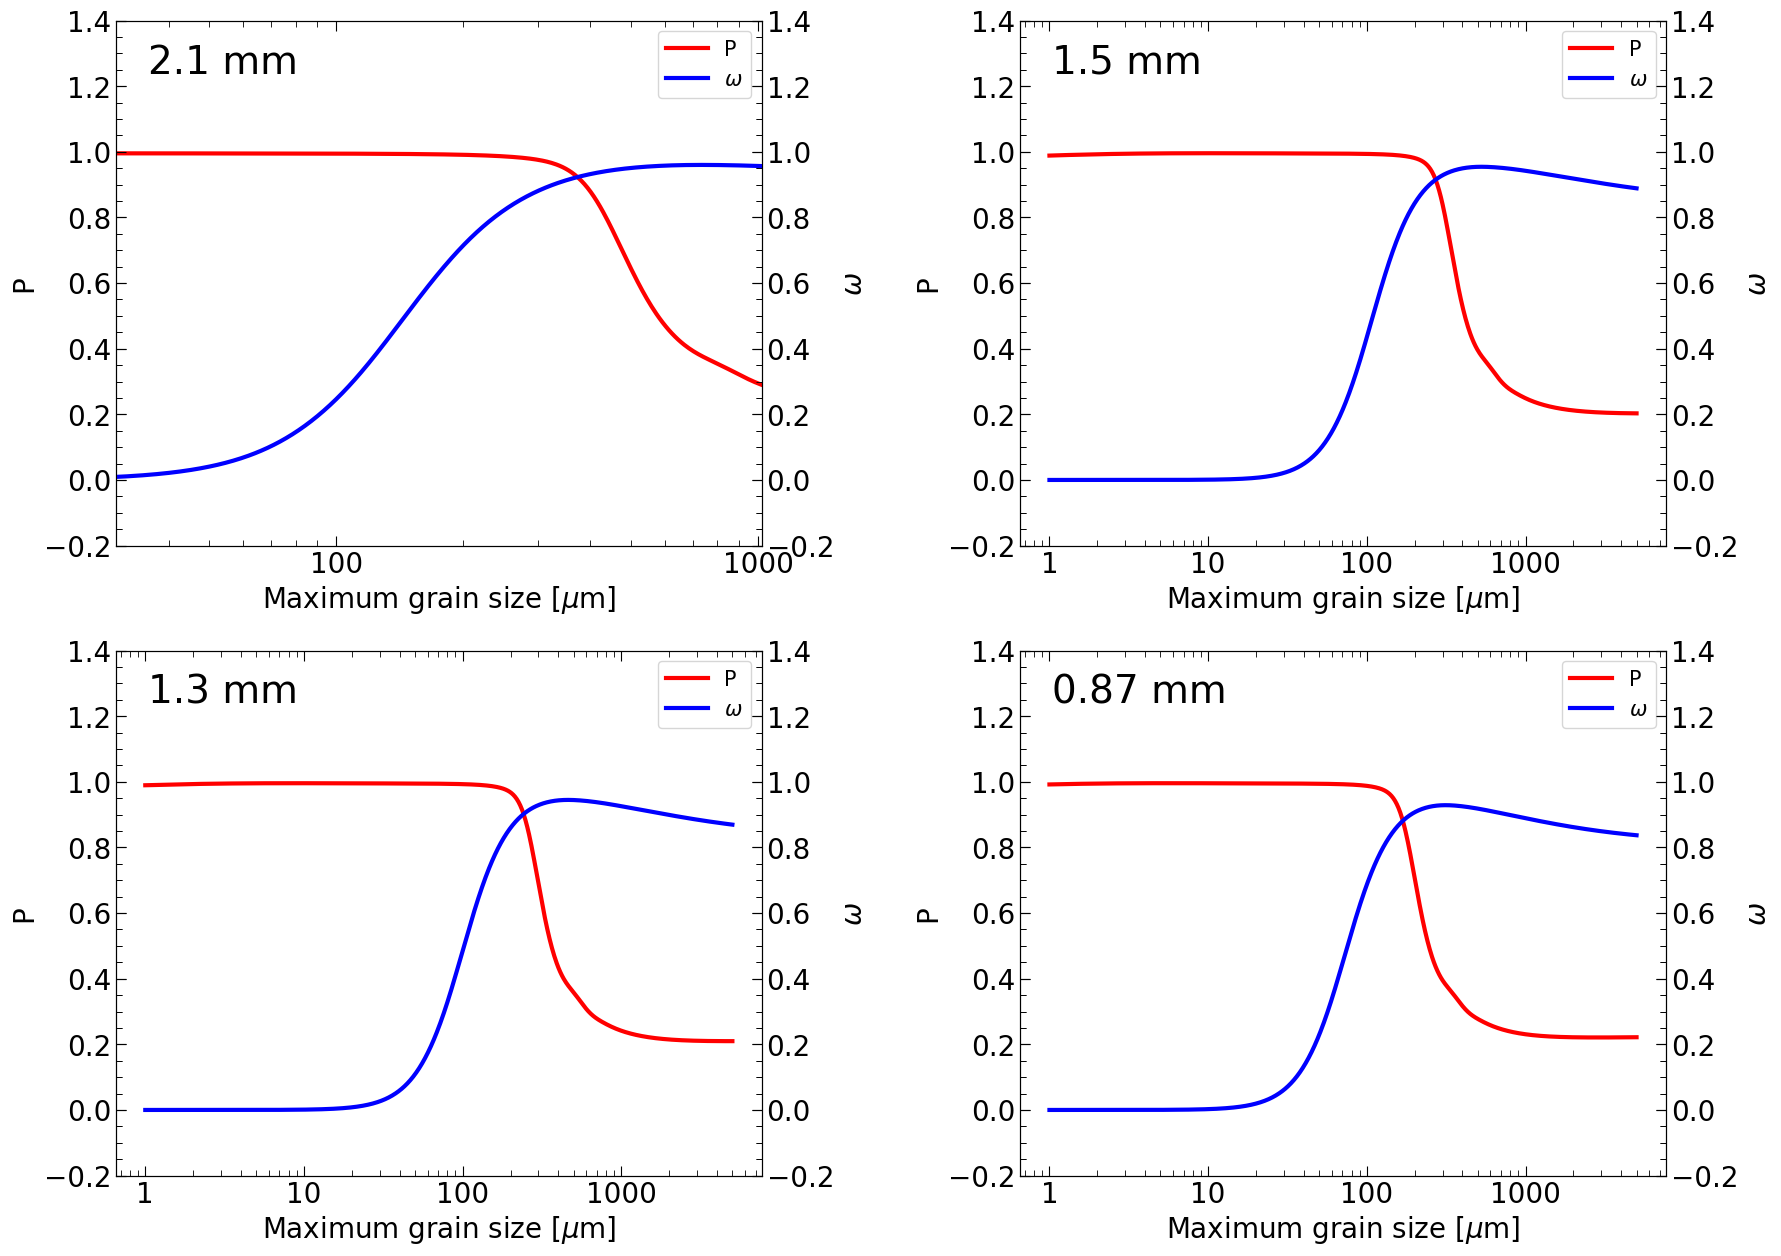

In [14]:
fig, ax = P_vs_omega_twin_axis(results, BandsIndex, lambda_bands_cm)

ax[0, 0].set_xlim(xmin, xmax)


plt.savefig(image_folder_path + '/Writeup/glitterin/' + "P_vs_w_vs_grainsize_grid.pdf", 
            dpi=1000, 
            bbox_inches='tight')

# P$\omega$ vs maximum grain size

Band 4 nterms2
Band 5 robust -1
Band 6
Band 7 nterms2


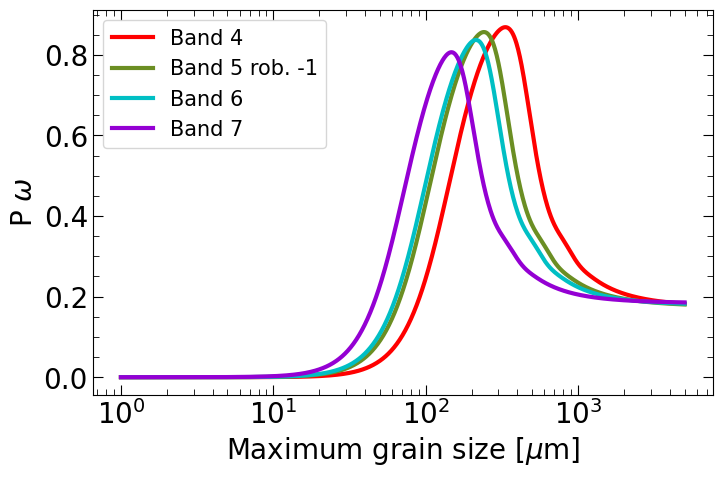

In [15]:
fig, ax = Pomega_Plot(results, BandsIndex)

# P$\omega$ vs maximum grain size, with scale factor

In [16]:
POLF_index = 'max Stokes I'

In [17]:
# poster_x_cm = 27.2
# poster_y_cm = 16.65

# current_figx = 7
# current_slides_x_cm = 46.88

# # Get figx from width only
# figx = current_figx * poster_x_cm / current_slides_x_cm

# # Force correct aspect ratio
# figy = figx * (poster_y_cm / poster_x_cm)

# print(figx, figy)

# #print(rf"My poster scale is: {poster_scale}")

# #poster_scale = 3
# # --------------------------------------------------------------------------------------

# BandsInFit_all = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]


# sf_results_all = find_sf_glitterin(results, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_all, results, sf_results_all, df_POLF,
#                                             for_poster = True, 
#                                              fig_x_size = figx, fig_y_size = figy,
#                                             poster_scale = 0.35)

# rows_DSHARP.append(
#     make_fit_summary_row(
#         fit_name = "All",
#         sf_results = sf_results_all,
#         nk = 'DSHARP',
#     )
# )

# fig.subplots_adjust(
#     left=0.15,
#     right=0.96,
#     bottom=0.2,
#     top=0.94
# )


# plt.savefig(image_folder_path + '/POSTER/' + "BestGlitterinPw.png", 
#             dpi=300, 
#             #bbox_inches='tight',
#             facecolor='white')

In [18]:
x = results['Band 4 nterms2']['rvol_max_cm'] * 10000

print(min(x))
print(max(x))
print(len(x))

1.0
5000.0
1000


The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True

best_idx: 628
Best rvol_max_cm: 0.021148445049916385
Best SF: 1.7624600745724694
Best SF std: 0.06542235141486173
j = 0, len(ms) = 4, band = Band 4 nterms2
[Band 4]
Fix chi^2
j = 1, len(ms) = 4, band = Band 5 robust -1
[Band 5 rob. -1]
Fix chi^2
j = 2, len(ms) = 4, band = Band 6
[Band 6]
Fix chi^2
j = 3, len(ms) = 4, band = Band 7 nterms2
[Band 7]
Fix chi^2


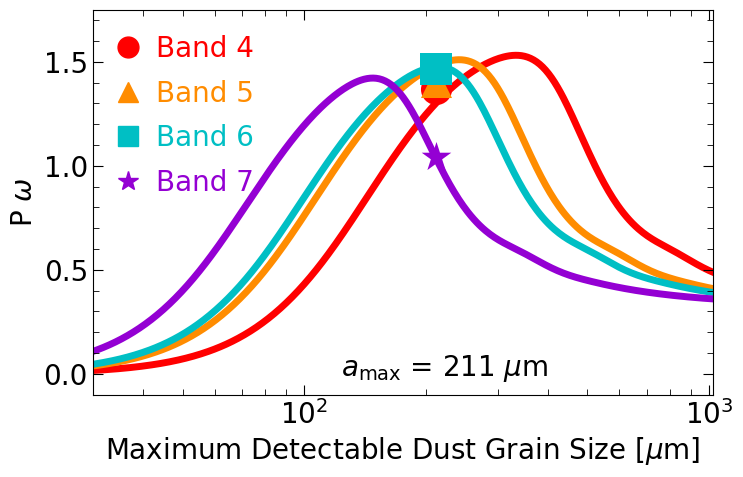

In [19]:

BandsInFit_all = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]


sf_results_all = find_sf_glitterin(results, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_all, results, sf_results_all, df_POLF,
                                            chi_sq_precision=4,
                                            for_slideshow = True,
                                             xmin = xmin, xmax = xmax,
                                            plot_sf = 1,
                                            BandLegend_bbox_to_anchor = (0.3, 1.0),)

# xmin = 30#1e-3 + 20
# xmax = 1e3 + 20

# ax.set_xlim(xmin, xnax)

ax.set_ylim(-0.1, 1.75)

rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'DSHARP',
    )
)

ax.set_xlabel('Maximum Detectable Dust Grain Size [$\mu$m]')

plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "BestGlitterin.jpeg", 
            dpi=1000, 
            bbox_inches='tight')


plt.savefig(image_folder_path + '/Writeup/glitterin/' + "BestGlitterin.png", 
            dpi=1000, 
            bbox_inches='tight')

In [20]:
# raise SystemExit("Stop here")

The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True

best_idx: 630
Best rvol_max_cm: 0.02151214846655107
Best SF: 1.8261396661478182
Best SF std: 0.03727978018520052
j = 0, len(ms) = 4, band = Band 4 nterms2
[Band 4]
Fix chi^2
j = 1, len(ms) = 4, band = Band 5 robust -1
[Band 5 rob. -1]
Fix chi^2
j = 2, len(ms) = 4, band = Band 6
[Band 6]
Fix chi^2
j = 3, len(ms) = 4, band = Band 7 nterms2
[Band 7]
Fix chi^2


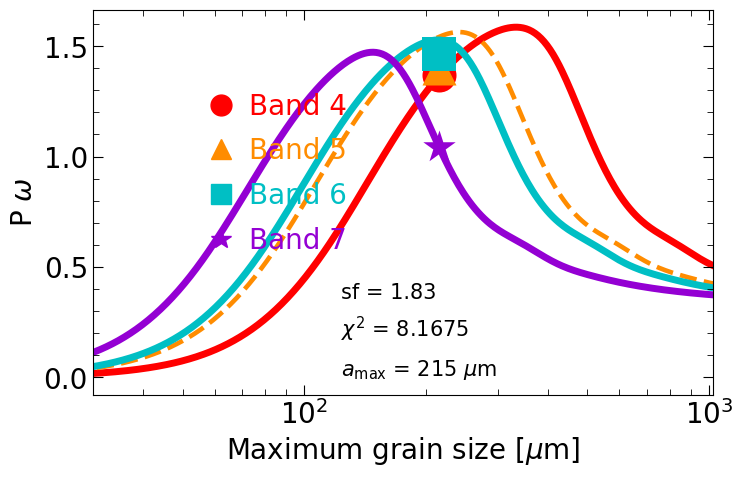

In [21]:
BandsInFit_wo5 = ["Band 4 nterms2", "Band 6", "Band 7 nterms2"]


sf_results_wo5 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo5, results, sf_results_wo5, df_POLF,
                                            chi_sq_precision=4)


rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'DSHARP',
    )
)

The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 7 nterms2']

 All rvol_max_cm are the same: True

best_idx: 628
Best rvol_max_cm: 0.021148445049916385
Best SF: 1.775469463543675
Best SF std: 0.0751289968516151
j = 0, len(ms) = 4, band = Band 4 nterms2
[Band 4]
Fix chi^2
j = 1, len(ms) = 4, band = Band 5 robust -1
[Band 5 rob. -1]
Fix chi^2
j = 2, len(ms) = 4, band = Band 6
[Band 6]
Fix chi^2
j = 3, len(ms) = 4, band = Band 7 nterms2
[Band 7]
Fix chi^2


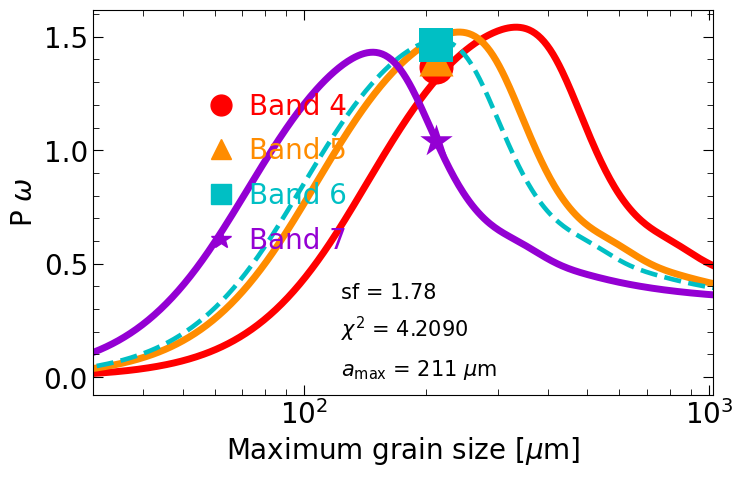

In [22]:
BandsInFit_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]


sf_results_wo6 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo6, results, sf_results_wo6, df_POLF)


rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'DSHARP',
    )
)

The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 7 nterms2']

 All rvol_max_cm are the same: True

best_idx: 820
Best rvol_max_cm: 0.10869050213794323
Best SF: 5.150134032796943
Best SF std: 0.0014727908389025046
j = 0, len(ms) = 4, band = Band 4 nterms2
[Band 4]
Fix chi^2
j = 1, len(ms) = 4, band = Band 5 robust -1
[Band 5 rob. -1]
Fix chi^2
j = 2, len(ms) = 4, band = Band 6
[Band 6]
Fix chi^2
j = 3, len(ms) = 4, band = Band 7 nterms2
[Band 7]
Fix chi^2


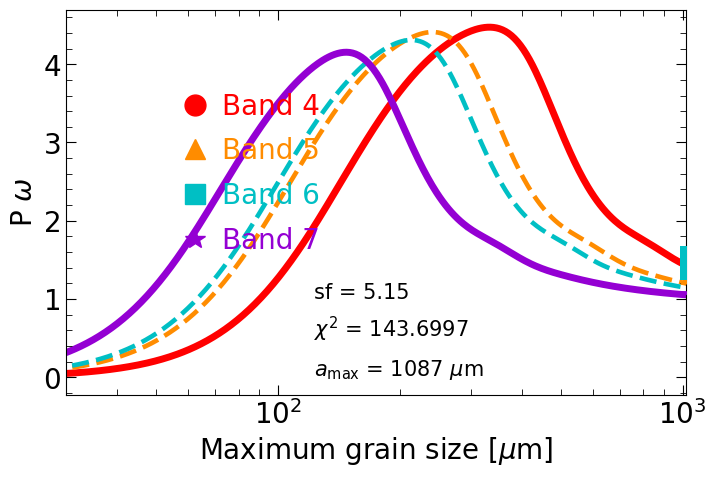

In [23]:
BandsInFit_just47 = ["Band 4 nterms2",  "Band 7 nterms2"]


sf_results_just47 = find_sf_glitterin(results, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_just47, results, sf_results_just47, df_POLF)

rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'DSHARP',
    )
)

# Testing Other Dust Things

## Hematite

In [24]:
# # fname = 'size_hematite.txt'
# # sizes = read_gals_size_table(fname, skiprows=2, out_type='container')


# data_n_Feldspar = {
#     'Band 4 nterms2': 1.5,
#     'Band 5': 1.5,
#     'Band 5 robust -1': 1.5,
#     'Band 6': 1.5,
#     'Band 7 nterms2': 1.5
# }

# data_k_Feldspar = {
#     'Band 4 nterms2': 1e-4,
#     'Band 5': 1e-4,
#     'Band 5 robust -1': 1e-4,
#     'Band 6': 1e-4,
#     'Band 7 nterms2': 1e-4
# }


In [25]:
# max_rvol_grid_cm = np.logspace(-3, 0, 100) 

# resultsFeldspar = RunGlitterinPowerLawDistAveraged(BandsIndex, 
#                                                    lambda_bands_cm, 
#                                                    data_n_Feldspar, 
#                                                    data_k_Feldspar,
#                                                    max_rvol_grid_cm)

# np.savez("results_glitterinFeldspar.npz", results=resultsFeldspar)

In [26]:
# data = np.load("results_glitterinFeldspar.npz", allow_pickle=True)

# resultsFeldspar = data["results"].item()


# # Testing Feldspar
# rows_Feldspar = []


# # All bands
# # ---------------------------------------------------------------------------------------------------
# sf_results_all = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

# rows_Feldspar.append(
#     make_fit_summary_row(
#         fit_name = "All",
#         sf_results = sf_results_all,
#         nk = 'Feldspar',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

# # Without 5
# # ---------------------------------------------------------------------------------------------------
# sf_results_wo5 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)


# rows_Feldspar.append(
#     make_fit_summary_row(
#         fit_name = "No 5",
#         sf_results = sf_results_wo5,
#         nk = 'Feldspar',
#     )
# )
# # ---------------------------------------------------------------------------------------------------
# # Without 6
# # ---------------------------------------------------------------------------------------------------

# sf_results_wo6 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)



# rows_Feldspar.append(
#     make_fit_summary_row(
#         fit_name = "No 6",
#         sf_results = sf_results_wo6,
#         nk = 'Feldspar',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

# # Just 4 and 7 

# # ---------------------------------------------------------------------------------------------------
# sf_results_just47 = find_sf_glitterin(resultsFeldspar, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

# rows_Feldspar.append(
#     make_fit_summary_row(
#         fit_name = "47",
#         sf_results = sf_results_just47,
#         nk = 'Feldspar',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

## Feldspar (THESE ARE SWAPPED)

In [27]:
# data_n_Hematite= {
#     'Band 4 nterms2': 3,
#     'Band 5': 3,
#     'Band 5 robust -1': 3,
#     'Band 6': 3,
#     'Band 7 nterms2': 3
# }

# data_k_Hematite = {
#     'Band 4 nterms2': 0.03,
#     'Band 5': 0.03,
#     'Band 5 robust -1': 0.03,
#     'Band 6': 0.03,
#     'Band 7 nterms2': 0.03
# }

In [28]:
# max_rvol_grid_cm = np.logspace(-3, 0, 100) 


# resultsHematite = RunGlitterinPowerLawDistAveraged(BandsIndex, 
#                                                    lambda_bands_cm, 
#                                                    data_n_Hematite, 
#                                                    data_k_Hematite, 
#                                                    max_rvol_grid_cm)

# np.savez("results_glitterinHematite.npz", results=resultsHematite)

In [29]:
# data = np.load("results_glitterinHematite.npz", allow_pickle=True)

# resultsHematite = data["results"].item()

# # Testing Hematite
# rows_Hematite = []


# # All bands
# # ---------------------------------------------------------------------------------------------------
# sf_results_all = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_all, df_POLF, POLF_index)

# rows_Hematite.append(
#     make_fit_summary_row(
#         fit_name = "All",
#         sf_results = sf_results_all,
#         nk = 'Hematite',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

# # Without 5
# # ---------------------------------------------------------------------------------------------------
# sf_results_wo5 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index)


# rows_Hematite.append(
#     make_fit_summary_row(
#         fit_name = "No 5",
#         sf_results = sf_results_wo5,
#         nk = 'Hematite',
#     )
# )
# # ---------------------------------------------------------------------------------------------------
# # Without 6
# # ---------------------------------------------------------------------------------------------------

# sf_results_wo6 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index)



# rows_Hematite.append(
#     make_fit_summary_row(
#         fit_name = "No 6",
#         sf_results = sf_results_wo6,
#         nk = 'Hematite',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

# # Just 4 and 7 

# # ---------------------------------------------------------------------------------------------------
# sf_results_just47 = find_sf_glitterin(resultsHematite, BandsIndex, BandsInFit_just47, df_POLF, POLF_index)

# rows_Hematite.append(
#     make_fit_summary_row(
#         fit_name = "47",
#         sf_results = sf_results_just47,
#         nk = 'Hematite',
#     )
# )
# # ---------------------------------------------------------------------------------------------------

# Results

In [30]:
df_DSHARP = pd.DataFrame(rows_DSHARP)

df_DSHARP

,Fit Case,nk,Scale Factor,Best amax (micron),Best Index
0,All,DSHARP,1.762460,211.484450,628
1,No 5,DSHARP,1.826140,215.121485,630
2,No 6,DSHARP,1.775469,211.484450,628
3,47,DSHARP,5.150134,1086.905021,820


In [31]:
# df_Feldspar = pd.DataFrame(rows_Feldspar)

# df_Feldspar

In [32]:
# df_Hematite = pd.DataFrame(rows_Hematite)

# df_Hematite